# Helical acquisition and reconstruction testing

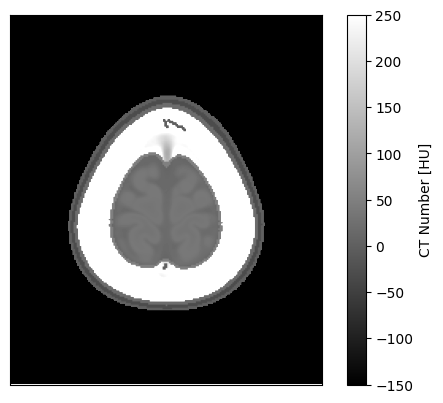

In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt

from insilicoICH.ground_truth_definition.phantoms import NIHPD_Head

from utils import ctshow

nihpd_dir = Path('../phantom_dir/NIHPD_Head_Phantom')
nihpd = NIHPD_Head(nihpd_dir, age=11.5)

vol = nihpd.get_CT_number_phantom()
im = ctshow(vol[len(vol)//2])
plt.colorbar(im, label='CT Number [HU]')

In [2]:
from insilicoICH.image_acquisition import Scanner

nihpd.patient_name = 'helical_test'
scanner = Scanner(nihpd)
scanner

Initializing Scanner object...
----------
*
*********************************************
* DICOM dataset information:
* Patient age: 000Y, sex: O
* Scanner: GE MEDICAL SYSTEMS RHAPSODE
* Study date & desciption: 20040119, e+1
* Technique: 120 kVp, 170 mA
* Reconstruction: STANDARD kernel, 338.671600-mm FOV
* Image: 1.0-mm pixels (XY), 1.0-mm slices (Z)
*********************************************
*
*********************************************
* Segmentation parameters:
* Using thresholds specified in the config file.
* Materials: ['ncat_adipose', 'ncat_water', 'ncat_brain', 'ncat_skull']
* mu values (/cm): [0.18, 0.21, 0.21, 0.46]
* mu(water) (/cm): 0.21
* Thresholds (/cm): [0.16, 0.2, 0.21, 0.27]
* Thresholds (HU): [-200.0, -10.0, 10.0, 300.0]
*********************************************
* Calculating volume fraction maps for 4 materials and 189 slices...
* Writing volume fraction files for 4 materials and 189 slices, plus the HU data...
* Writing helical_test/phantoms/0/0_ncat_ad


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        

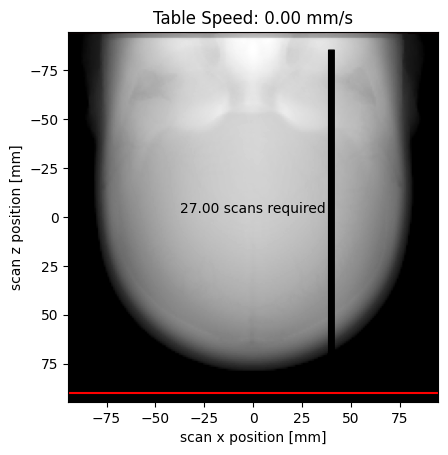

In [3]:
scanner.scout_view()

In [4]:
print(scanner.xcist.cfg.protocol.startZ,
scanner.xcist.cfg.protocol.viewsPerRotation,
scanner.xcist.cfg.protocol.viewCount,
scanner.xcist.cfg.protocol.tableSpeed, 
scanner.xcist.cfg.protocol.stopViewId,
scanner.xcist.cfg.recon.sliceCount)

0 1000 1000 0 999 1


9 4500
Airscan
Offset scan


Phantom scan


  0%|          | 0/4500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 4500/4500 [19:54<00:00,  3.77it/s]


Prep view
Applying LSC...done.

Simulation is done.
1
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/180...
   recon slice 1/180...
   recon slice 2/180...
   recon slice 3/180...
   recon slice 4/180...
   recon slice 5/180...
   recon slice 6/180...
   recon slice 7/180...
   recon slice 8/180...
   recon slice 9/180...
   recon slice 10/180...
   recon slice 11/180...
   recon slice 12/180...
   recon slice 13/180...
   recon slice 14/180...
   recon slice 15/180...
   recon slice 16/180...
   recon slice 17/180...
   recon slice 18/180...
   recon slice 19/180...
   recon slice 20/180...
   recon slice 21/180...
   recon slice 22/180...
   recon slice 23/180...
   recon slice 24/180...
   recon slice 25/180...
   recon slice 26/180...
   recon slice 27/180...
   recon slice 28/180...
   recon slice 29/180

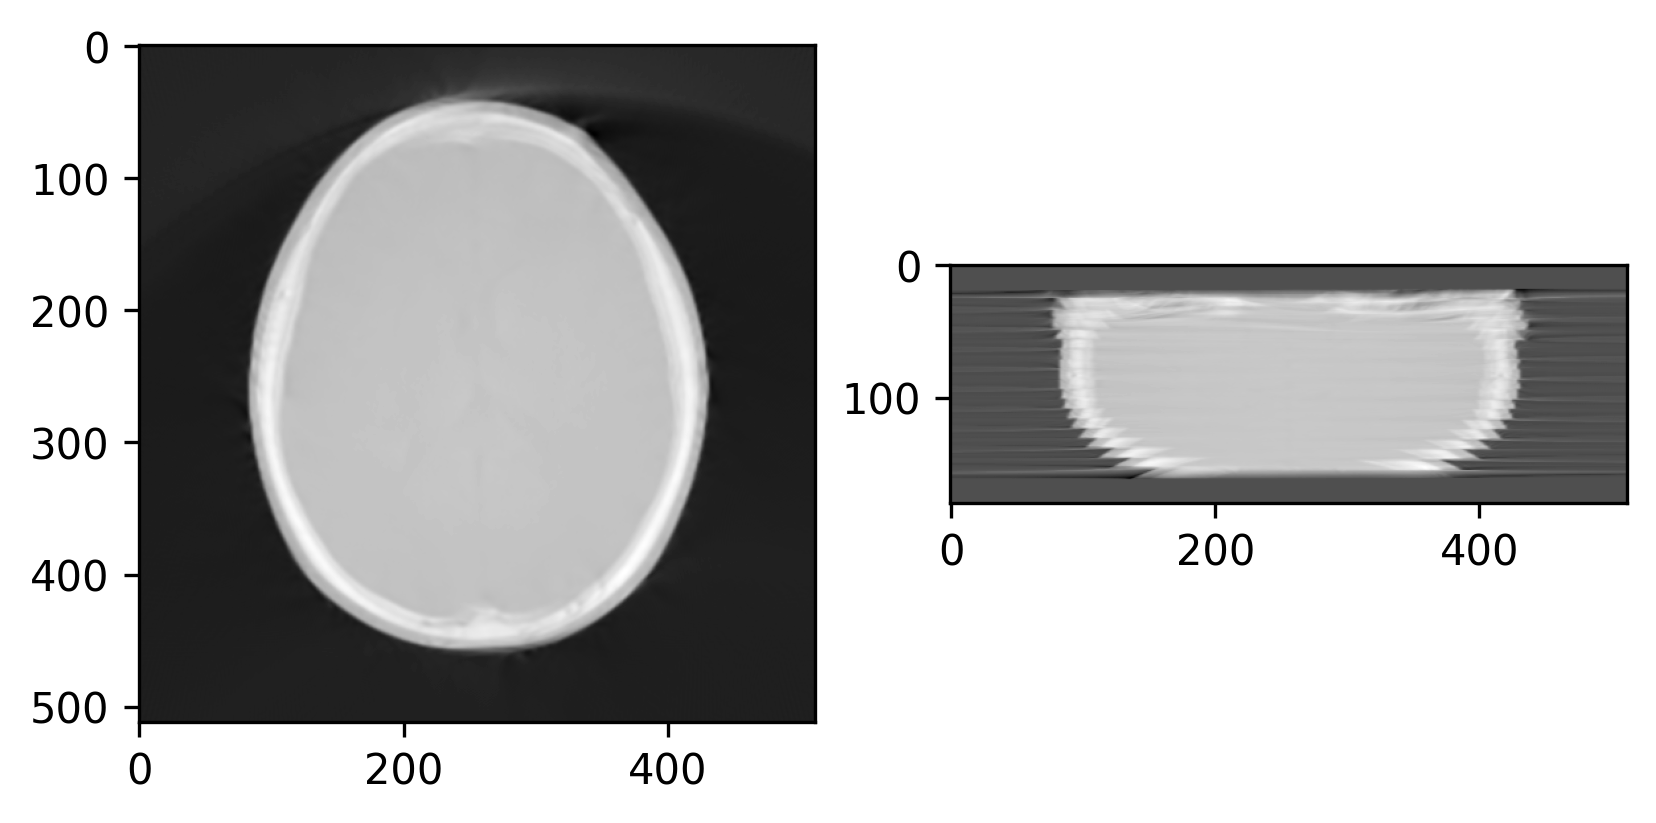

In [5]:
import gecatsim as xc
import numpy as np
from gecatsim.reconstruction.pyfiles import recon

##--------- Initialize 
ct = xc.CatSim("../src/insilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/insilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/insilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/insilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/insilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

##--------- Make changes to parameters (optional)
# ct.phantom.filename = 'water20.ppm'
#ct.phantom.filename = 'CTDI_16cm_WaterAirPEBoneChambers.ppm'
ct.phantom.filename = scanner.xcist.cfg.phantom.filename
# rotations =

## my code
endZ = 75
ct.cfg.protocol.startZ = -75
exam_length = endZ - ct.cfg.protocol.startZ 
detector_width = ct.cfg.scanner.detectorRowSize*ct.cfg.scanner.detectorRowCount
rotations = np.floor(exam_length / detector_width).astype(int) # assuming pitch = 1 #NEEDS to INT (consider CEIL instead of INT/floor, what does that do?)
## end my code

views = 500

ct.cfg.protocol.viewsPerRotation = views
ct.cfg.protocol.viewCount = rotations * ct.cfg.protocol.viewsPerRotation# 900
print(rotations, ct.cfg.protocol.viewCount)
ct.cfg.protocol.tableSpeed = 30 
ct.cfg.protocol.stopViewId = ct.cfg.protocol.startViewId+ct.cfg.protocol.viewCount-1
ct.cfg.recon.sliceCount = 180
ct.resultsName = "test_Helical"

#scanner.scout_view(startZ=0)

##--------- Run simulation
ct.run_all()  # run the scans defined by protocol.scanTypes


if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

cfg.recon.sliceThickness = 1
print(cfg.recon.sliceThickness)

cfg.do_Recon = 1
cfg.waitForKeypress = 0
cfg.recon.printReconParameters = False
vol = recon.recon_direct(cfg).transpose(2, 0, 1)

ww, wl = 80, 40
disp = dict(cmap='gray')
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(vol[len(vol)//2], **disp)
axs[1].imshow(vol[:, 256], **disp)

import gecatsim as xc
from gecatsim.reconstruction.pyfiles import recon

##--------- Initialize 
ct = xc.CatSim("../src/insilicoICH/defaults/helical_cfg/Phantom_Sample_Analytic",
               "../src/insilicoICH/defaults/helical_cfg/Protocol_Sample_Helical",
               "../src/insilicoICH/defaults/helical_cfg/Scanner_Sample_generic",
               "../src/insilicoICH/defaults/helical_cfg/Physics_Sample",
               "../src/insilicoICH/defaults/helical_cfg/Recon_Sample_Helical",
        )  # initialization

##--------- Make changes to parameters (optional)
# ct.phantom.filename = 'water20.ppm'
#ct.phantom.filename = 'CTDI_16cm_WaterAirPEBoneChambers.ppm'
ct.phantom.filename = scanner.xcist.cfg.phantom.filename
# rotations =
ct.cfg.protocol.startZ = -75
ct.cfg.protocol.viewsPerRotation = 100
ct.cfg.protocol.viewCount = 900
ct.cfg.protocol.tableSpeed = 30 
ct.cfg.protocol.stopViewId = ct.cfg.protocol.startViewId+ct.cfg.protocol.viewCount-1
ct.cfg.recon.sliceCount = 180
ct.resultsName = "test_Helical"

#scanner.scout_view(startZ=0)

##--------- Run simulation
ct.run_all()  # run the scans defined by protocol.scanTypes


if ct.physics.monochromatic>0:
        ct.recon.mu = xc.GetMu('water', ct.physics.monochromatic)[0]/10

cfg = ct.get_current_cfg()

cfg.recon.sliceThickness = 1
print(cfg.recon.sliceThickness)

cfg.do_Recon = 1
cfg.waitForKeypress = 0
cfg.recon.printReconParameters = False
vol = recon.recon_direct(cfg).transpose(2, 0, 1)

plt.imshow(vol.mean(axis=1), cmap='gray')

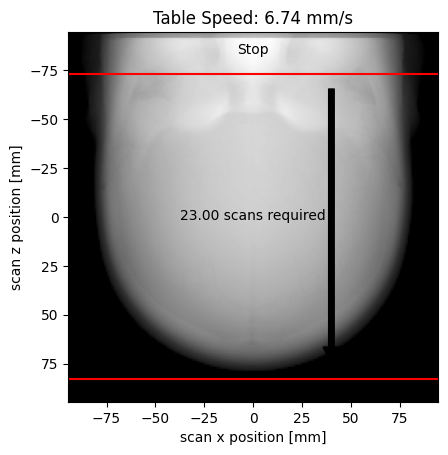

In [6]:
acquisition_technique = dict(
    startZ=-75,
    endZ=80,
    pitch=1)
scanner.scout_view(**acquisition_technique)

In [7]:
import numpy as np
import pandas as pd

In [8]:
scanner.rotations_per_scan(**acquisition_technique), views, np.ceil(views*scanner.rotations_per_scan(**acquisition_technique))

(np.int64(23), 500, np.int64(11500))

Check that the total number of views is what you'd expect based on the number of rotations and views per rotation:

Airscan
Offset scan
Phantom scan


  0%|          | 0/11500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


  1%|          | 109/11500 [00:26<47:51,  3.97it/s]

100%|██████████| 11500/11500 [45:49<00:00,  4.18it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/155...
   recon slice 1/155...
   recon slice 2/155...
   recon slice 3/155...
   recon slice 4/155...
   recon slice 5/155...
   recon slice 6/155...
   recon slice 7/155...
   recon slice 8/155...
   recon slice 9/155...
   recon slice 10/155...
   recon slice 11/155...
   recon slice 12/155...
   recon slice 13/155...
   recon slice 14/155...
   recon slice 15/155...
   recon slice 16/155...
   recon slice 17/155...
   recon slice 18/155...
   recon slice 19/155...
   recon slice 20/155...
   recon slice 21/155...
   recon slice 22/155...
   recon slice 23/155...
   recon slice 24/155...
   recon slice 25/155...
   recon slice 

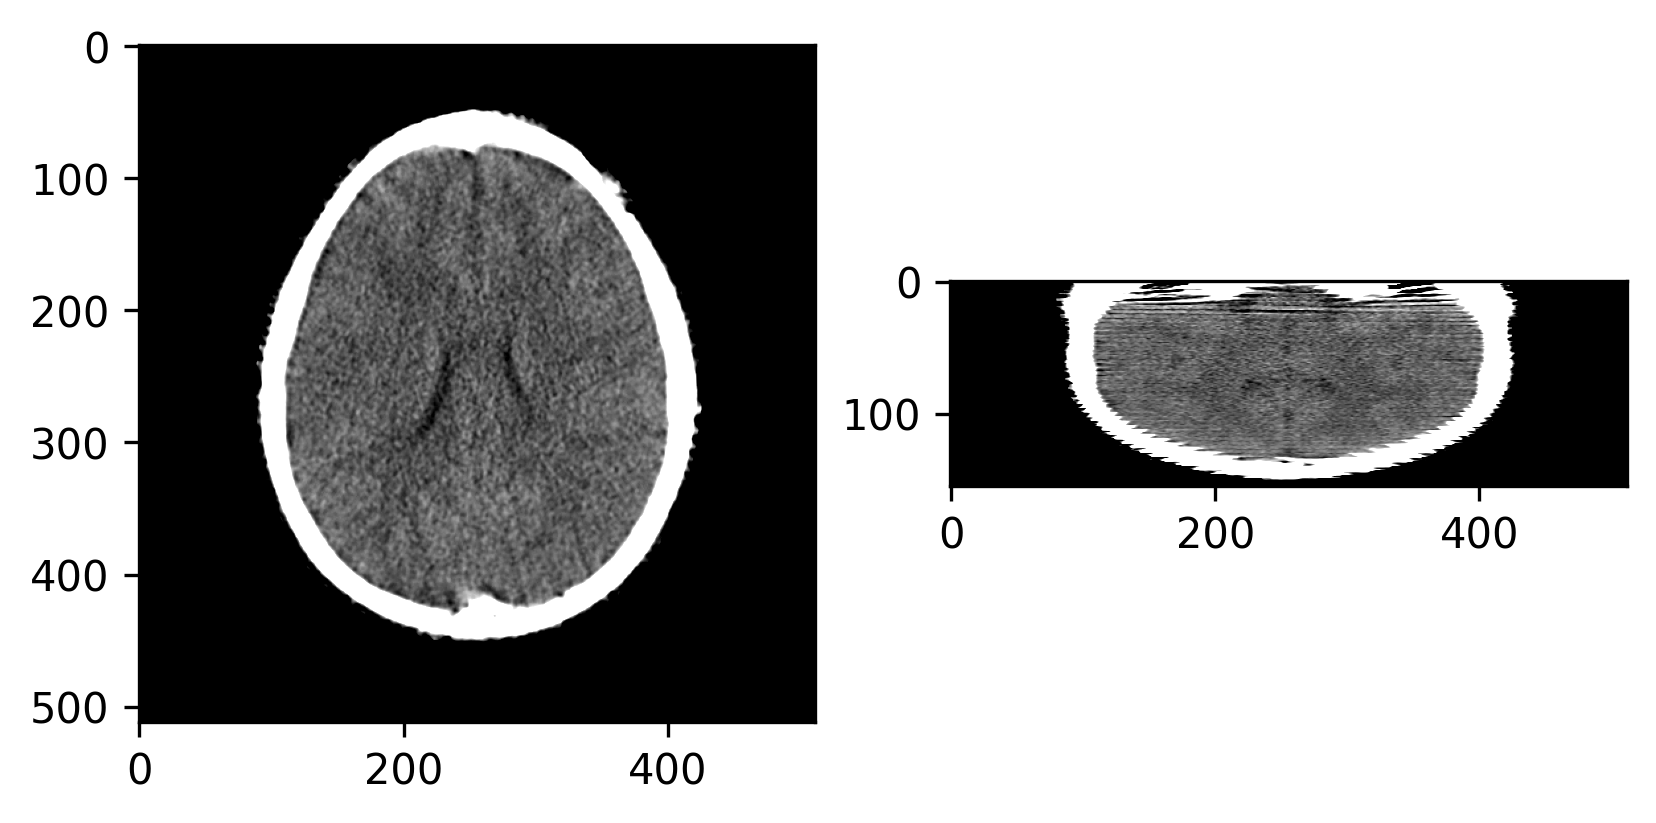

In [9]:
# %%time
acquisition_technique['views'] = views
acquisition_technique['mA'] = 500
recon_technique = dict(kernel='soft')

scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

ww, wl = 80, 40
disp = dict(cmap='gray', vmin=wl-ww/2, vmax=wl+ww/2)
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[len(scanner.recon)//2], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

scan: 1/22
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


 35%|███▌      | 175/500 [00:41<01:26,  3.77it/s]

100%|██████████| 500/500 [01:59<00:00,  4.18it/s]


...

Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
scan: 22/22
Airscan
Offset scan
Phantom scan


  0%|          | 0/500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


100%|██████████| 500/500 [02:39<00:00,  3.13it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
* Converting the recon results from a C array to a numpy array...
* Scaling recon data...
* Loading the projection data...
* Pre-weighting the filter...
* Applying the filter...
* Running the reconstruction...
* Converting projection data from a numpy array to a C array...
* Allocating a C 

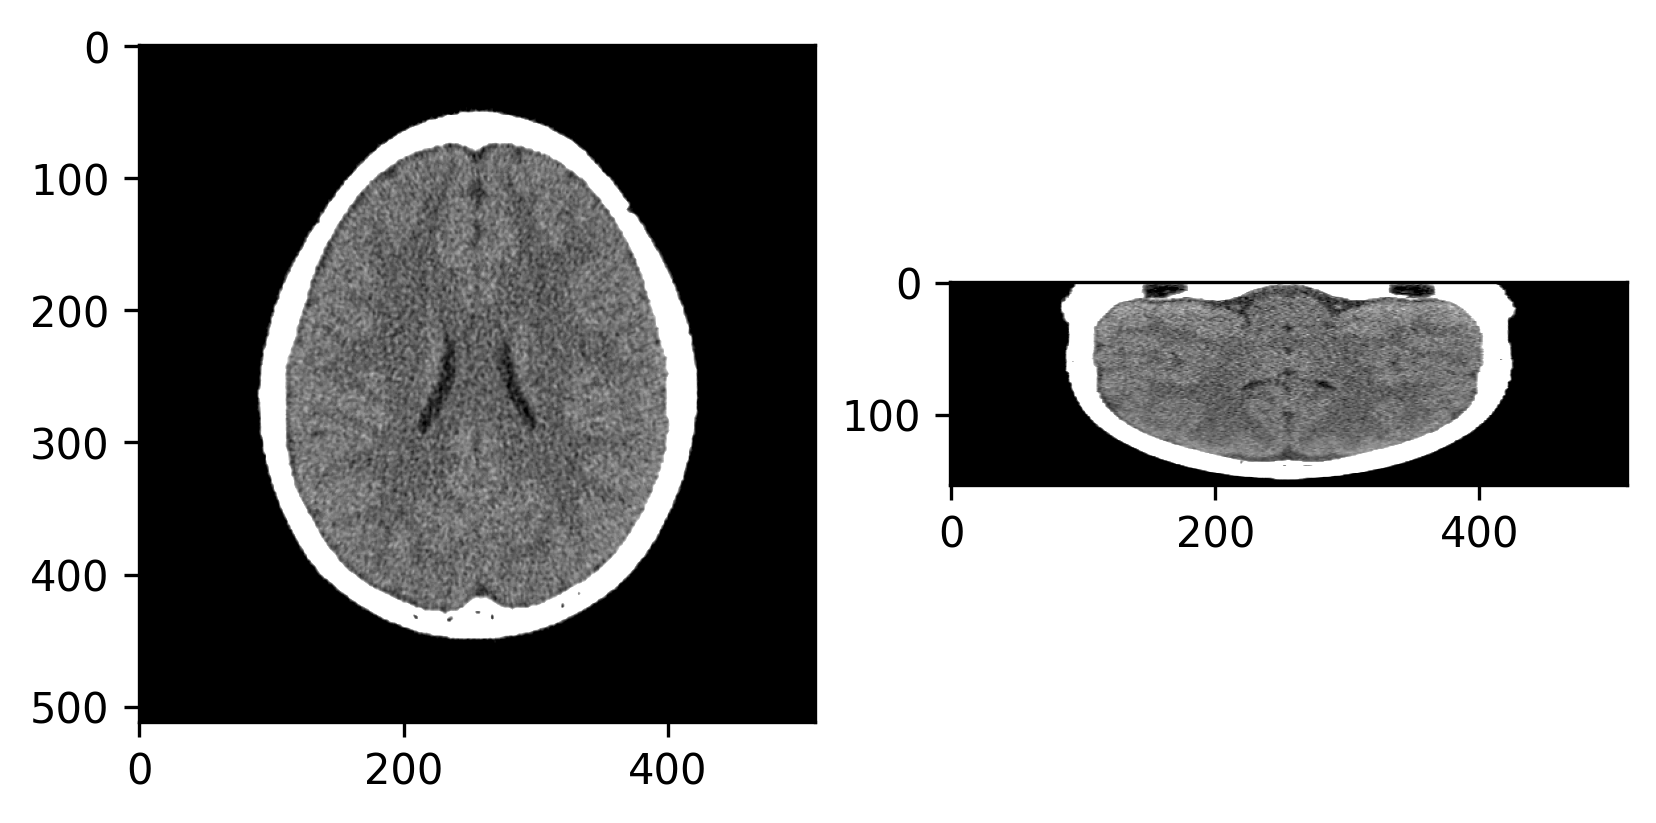

In [10]:
%%time
acquisition_technique['pitch'] = 0

scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[len(scanner.recon)//2], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

For pitch = 1, axial and helical are similar, but by increasing the pitch the scan can be completed faster, or by reducing the pitch the dose can increase reducing noise

Airscan
Offset scan
Phantom scan


  0%|          | 0/7500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


  3%|▎         | 224/7500 [01:00<30:31,  3.97it/s]

100%|██████████| 7500/7500 [36:46<00:00,  3.40it/s]


Prep view
Applying LSC...done.

Applying Beam Hardening Correction (ACCURATE BHC)...Airscan
done.

Simulation is done.
fov size: 250.0
* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/155...
   recon slice 1/155...
   recon slice 2/155...
   recon slice 3/155...
   recon slice 4/155...
   recon slice 5/155...
   recon slice 6/155...
   recon slice 7/155...
   recon slice 8/155...
   recon slice 9/155...
   recon slice 10/155...
   recon slice 11/155...
   recon slice 12/155...
   recon slice 13/155...
   recon slice 14/155...
   recon slice 15/155...
   recon slice 16/155...
   recon slice 17/155...
   recon slice 18/155...
   recon slice 19/155...
   recon slice 20/155...
   recon slice 21/155...
   recon slice 22/155...
   recon slice 23/155...
   recon slice 24/155...
   recon slice 25/155...
   recon slice 

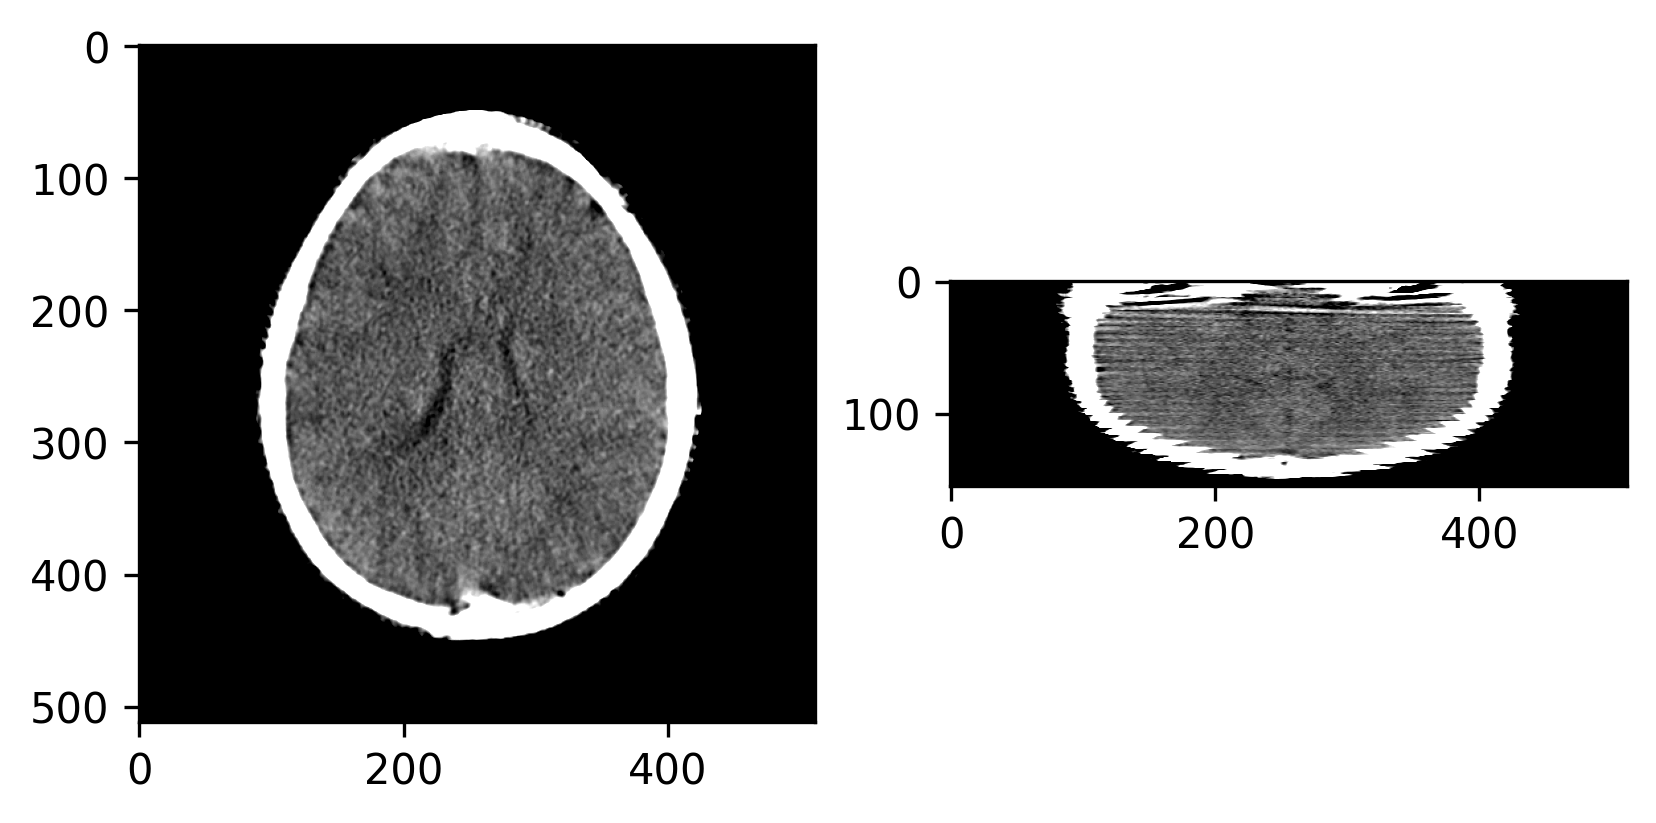

In [ ]:
%%time
acquisition_technique['pitch'] = 1.5

scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[len(scanner.recon)//2], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

In [ ]:
%%time
acquisition_technique['pitch'] = 0.5

scanner.run_scan(**acquisition_technique)
scanner.run_recon(**recon_technique)

f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(scanner.recon[len(scanner.recon)//2], **disp)
axs[1].imshow(scanner.recon[:, 256], **disp)

Airscan
Offset scan
Phantom scan


  0%|          | 0/22500 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of    132 MB.


  0%|          | 111/22500 [00:26<1:32:48,  4.02it/s]

In [ ]:
scanner.xcist.cfg.protocol.viewsPerRotation = 100
scanner.xcist.cfg.protocol.startZ = -75
endZ = 75
scanner.xcist.cfg.recon.sliceThickness = 1
scanner.xcist.cfg.protocol.rotationTime = 1
scanner.pitch = 1

# scanner.xcist.cfg.scanner.detectorRowCount = 64

# do not edit below
table_feed_per_rotation = scanner.pitch*scanner.scan_width

scanner.calculate_start_positions()
scanner.xcist.cfg.protocol.scanTrajectory = "Gantry_Helical"

scanner.xcist.cfg.protocol.spectrumFilename = "xcist_kVp120_tar7_bin1.dat"

exam_range = endZ - scanner.xcist.cfg.protocol.startZ
table_feed_per_rotation = scanner.scan_width * scanner.pitch # distance covered in mm in a 360 degree scan rotation
rotations = exam_range / table_feed_per_rotation
scanner.xcist.cfg.protocol.startViewId = -100
scanner.xcist.cfg.protocol.viewCount = np.ceil(scanner.xcist.cfg.protocol.viewsPerRotation*rotations).astype(int)
scanner.xcist.cfg.protocol.stopViewId = scanner.xcist.cfg.protocol.startViewId+scanner.xcist.cfg.protocol.viewCount-1

scan_duration = rotations * scanner.xcist.cfg.protocol.rotationTime
scanner.xcist.cfg.protocol.tableSpeed = exam_range / scan_duration

pd.DataFrame({'exam range [mm]': [exam_range], #  total scan coverage after all rotations
              'scan range [mm]': [scanner.scan_width], #  scan coverage after a single rotation
              'scan duration [s]': [scan_duration],
              'rotations': [rotations],
              'view count': [scanner.xcist.cfg.protocol.viewCount],
              'table speed [mm/s]': [scanner.xcist.cfg.protocol.tableSpeed]})

,exam range [mm],scan range [mm],scan duration [s],rotations,view count,table speed [mm/s]
0,150,7.094737,21.142433,21.142433,2115,7.094737


In [ ]:
sliceCount = int(exam_range / scanner.xcist.cfg.recon.sliceThickness)
scanner.xcist.cfg.recon.reconType = 'helical_equiAngle'
scanner.xcist.cfg.recon.sliceCount = sliceCount
scanner


        <class 'insilicoICH.image_acquisition.Scanner'> default
        Scanner: Scanner_Default
        Simulation Platform: CATSIM
        
Recon: (155, 512, 512) 25.0 cm fov
Projections: (4300, 16, 900)

In [ ]:
scanner.xcist.run_all()

Airscan
Offset scan
Phantom scan


  0%|          | 0/2115 [00:00<?, ?it/s]

in C> Preparing to allocate memory for material volume data...
in C> Allocated memory for image volume for material  1
in C> Copying data for material  1 into C memory...in C>  done.
in C> Allocated memory for image volume for material  2
in C> Copying data for material  2 into C memory...in C>  done.
in C> Allocated memory for image volume for material  3
in C> Copying data for material  3 into C memory...in C>  done.
in C> Allocated memory for image volume for material  4
in C> Copying data for material  4 into C memory...in C>  done.
in C> Allocated a total of     10 MB.


 53%|█████▎    | 1114/2115 [01:26<01:33, 10.74it/s]

In [ ]:
from gecatsim.reconstruction.pyfiles import recon
vol = recon.recon_direct(scanner.xcist.cfg).transpose(2, 0, 1)
vol.shape

* Loading the projection data...
* Rebinning the projection...
* Applying the filter...
* Converting projection data from a numpy array to a C array...
* Allocating a C array for the recon results...
* In C...
   recon slice 0/150...
   recon slice 1/150...
   recon slice 2/150...
   recon slice 3/150...
   recon slice 4/150...
   recon slice 5/150...
   recon slice 6/150...
   recon slice 7/150...
   recon slice 8/150...
   recon slice 9/150...
   recon slice 10/150...
   recon slice 11/150...
   recon slice 12/150...
   recon slice 13/150...
   recon slice 14/150...
   recon slice 15/150...
   recon slice 16/150...
   recon slice 17/150...
   recon slice 18/150...
   recon slice 19/150...
   recon slice 20/150...
   recon slice 21/150...
   recon slice 22/150...
   recon slice 23/150...
   recon slice 24/150...
   recon slice 25/150...
   recon slice 26/150...
   recon slice 27/150...
   recon slice 28/150...
   recon slice 29/150...
   recon slice 30/150...
   recon slice 31/150...


   recon slice 65/150...
   recon slice 66/150...
   recon slice 67/150...
   recon slice 68/150...
   recon slice 69/150...
   recon slice 70/150...
   recon slice 71/150...
   recon slice 72/150...
   recon slice 73/150...
   recon slice 74/150...
   recon slice 75/150...
   recon slice 76/150...
   recon slice 77/150...
   recon slice 78/150...
   recon slice 79/150...
   recon slice 80/150...
   recon slice 81/150...
   recon slice 82/150...
   recon slice 83/150...
   recon slice 84/150...
   recon slice 85/150...
   recon slice 86/150...
   recon slice 87/150...
   recon slice 88/150...
   recon slice 89/150...
   recon slice 90/150...
   recon slice 91/150...
   recon slice 92/150...
   recon slice 93/150...
   recon slice 94/150...
   recon slice 95/150...
   recon slice 96/150...
   recon slice 97/150...
   recon slice 98/150...
   recon slice 99/150...
   recon slice 100/150...
   recon slice 101/150...
   recon slice 102/150...
   recon slice 103/150...
   recon slice 104/15

(150, 512, 512)

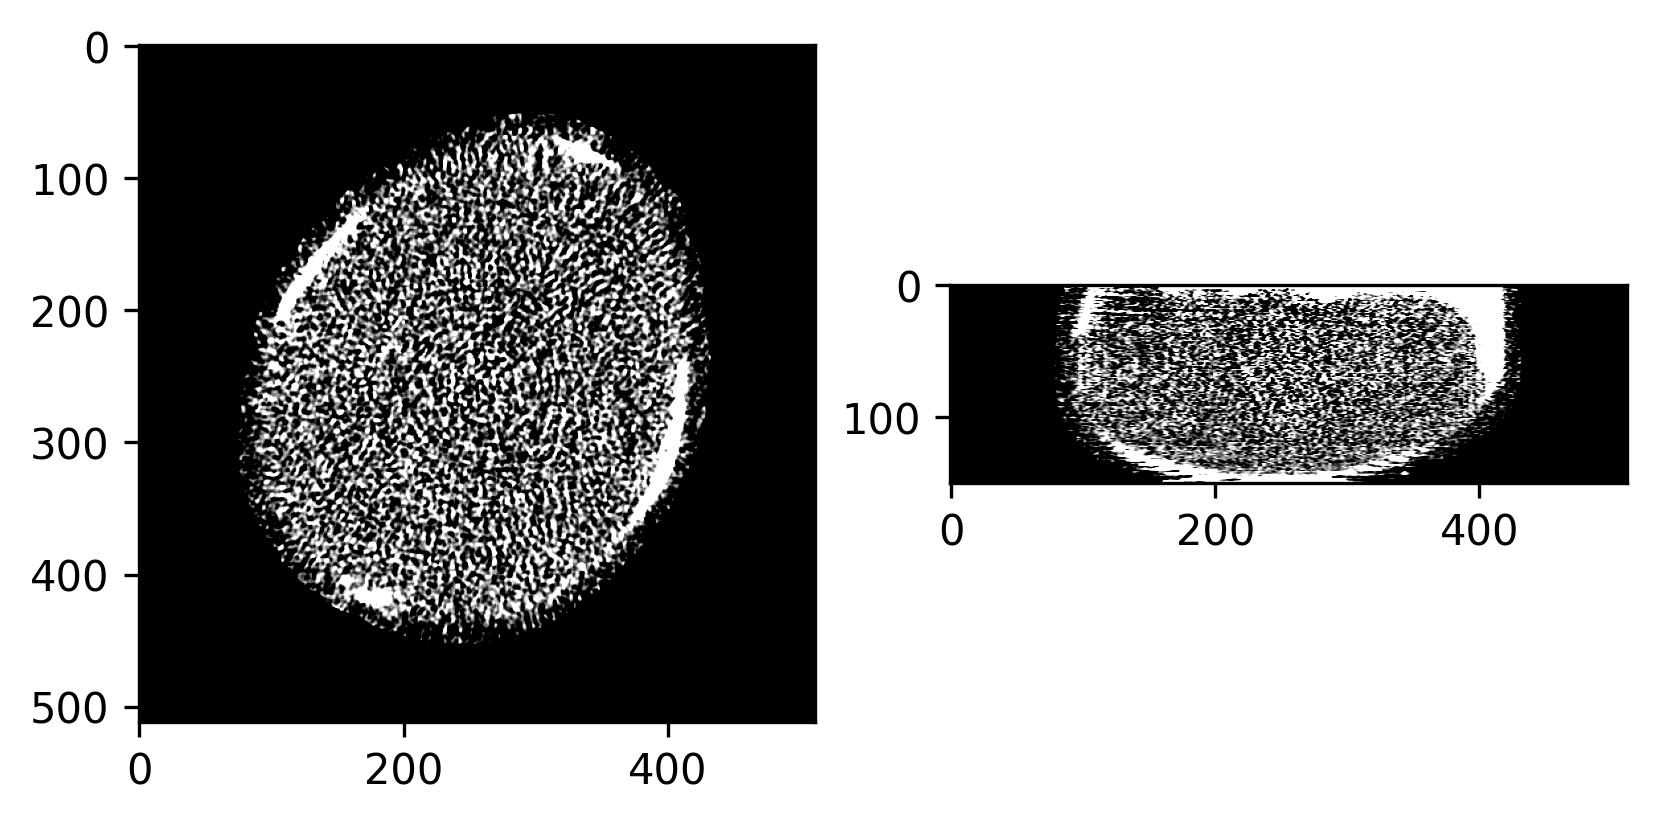

In [ ]:
f, axs = plt.subplots(1,2, dpi=300)
axs[0].imshow(vol[len(vol)//2], **disp)
axs[1].imshow(vol[:, 256], **disp)

In [ ]:
scanner.xcist.cfg.protocol.tableSpeed

7.094736842105263

In [ ]:
scanner.xcist.cfg.protocol.wobbleDistance

0.0